In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Definir las funciones de activación y entrenamiento
def step_function(x):
  return np.where(x>= 0,1,0)

#Función para hacer predicciones
def perceptron_predict(x, weights):
  y1 = step_function(np.dot(x, weights[0,1:]) + weights[0,0])
  y2 = step_function(np.dot(x, weights[1,1:]) + weights[1,0])

  return np.array([y1, y2])

In [ ]:
def train(X,y,learning_rate = 0.1, epochs = 10):
  #Inicializar pesos
  weights = np.random.rand(2, X.shape[1]+1) * 0.01 #shape (2,3) 2 neuronas, 2 entradas + bias
  errors = []

  for _ in range(epochs):
    total_error = np.zeros(2)
    for xi, targets in zip(X,y):
      outputs = perceptron_predict(xi, weights)
      error = targets - outputs
      total_error += np.abs(error)

      for i in range(2):
        update = learning_rate * error[i]
        weights[i,1:] += update * xi
        weights[i,0] += update #Actualizar bias
    errors.append(total_error)
  return weights, np.array(errors)

Pesos entrenados para la neurona 1 - and: [-0.29278579  0.1027945   0.10991888  0.10264816]
Pesos entrenados para la neurona 2 - or: [-0.09047751  0.10644938  0.10167168  0.10392228]


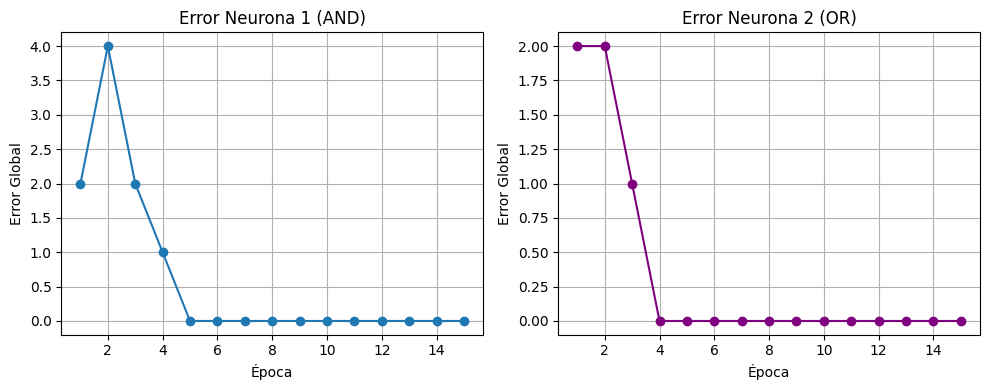

In [ ]:
# Preparar los datos
X = np.array([[0, 0, 0],
              [0, 0, 1],
              [1, 1, 0],
              [0, 1, 0],
              [1, 0, 1],
              [0, 1, 1],
              [1, 0, 0],
              [1, 1, 1],])

# Salidas en una matriz
y = np.array([[0, 0],
              [0, 1],
              [0, 1],
              [0, 1],
              [0, 1],
              [0, 1],
              [0, 1],
              [1, 1],])

weights, errors = train(X, y, learning_rate=0.1, epochs=15)
print("Pesos entrenados para la neurona 1 - and:", weights[0])
print("Pesos entrenados para la neurona 2 - or:", weights[1])

# Graficar errores
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(errors) + 1), errors[:, 0], marker='o')
plt.xlabel('Época')
plt.ylabel('Error Global')
plt.title('Error Neurona 1 (AND)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(errors) + 1), errors[:, 1], marker='o', color='purple')
plt.xlabel('Época')
plt.ylabel('Error Global')
plt.title('Error Neurona 2 (OR)')
plt.grid(True)

plt.tight_layout()
plt.show()




In [ ]:
print('COMPUERTA AND')
for xi in X:
    prediction = perceptron_predict(xi, weights)
    print(f"Entrada: {xi}, Salida predicha: {prediction[0]}")

print('\nCOMPUERTA OR')
for xi in X:
    prediction = perceptron_predict(xi, weights)
    print(f"Entrada: {xi}, Salida predicha: {prediction[1]}")


COMPUERTA AND
Entrada: [0 0 0], Salida predicha: 0
Entrada: [0 0 1], Salida predicha: 0
Entrada: [1 1 0], Salida predicha: 0
Entrada: [0 1 0], Salida predicha: 0
Entrada: [1 0 1], Salida predicha: 0
Entrada: [0 1 1], Salida predicha: 0
Entrada: [1 0 0], Salida predicha: 0
Entrada: [1 1 1], Salida predicha: 1

COMPUERTA OR
Entrada: [0 0 0], Salida predicha: 0
Entrada: [0 0 1], Salida predicha: 1
Entrada: [1 1 0], Salida predicha: 1
Entrada: [0 1 0], Salida predicha: 1
Entrada: [1 0 1], Salida predicha: 1
Entrada: [0 1 1], Salida predicha: 1
Entrada: [1 0 0], Salida predicha: 1
Entrada: [1 1 1], Salida predicha: 1


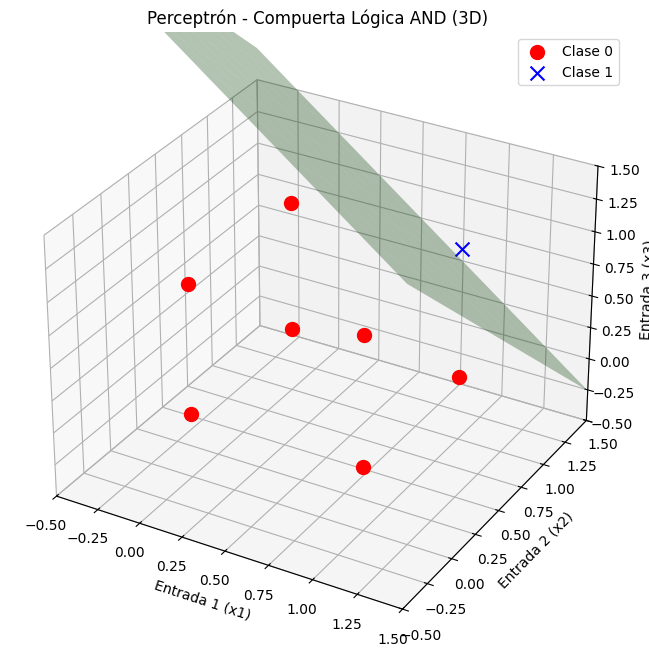

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Graficar los puntos de datos para neurona 1
for i, xi in enumerate(X):
    if y[i,0] == 0:
        ax.scatter(xi[0], xi[1], xi[2], color='red', marker='o', s=100, label='Clase 0' if i == 0 else "")
    else:
        ax.scatter(xi[0], xi[1], xi[2], color='blue', marker='x', s=100, label='Clase 1' if i == 7 else "")

# Definir el plano de decisión para AND
# w1*x1 + w2*x2 + w3*x3 + w0 = 0
# x3 = -(w1*x1 + w2*x2 + w0) / w3
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 10), np.linspace(-0.5, 1.5, 10))
zz = -(weights[0,1] * xx + weights[0,2] * yy + weights[0,0]) / weights[0,3]

# Graficar el plano de decisión
ax.plot_surface(xx, yy, zz, alpha=0.3, color='green')

# Configuraciones de la gráfica
ax.set_xlabel('Entrada 1 (x1)')
ax.set_ylabel('Entrada 2 (x2)')
ax.set_zlabel('Entrada 3 (x3)')
ax.legend()
ax.set_title('Compuerta Lógica AND (3D)')
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_zlim(-0.5, 1.5)

plt.show()

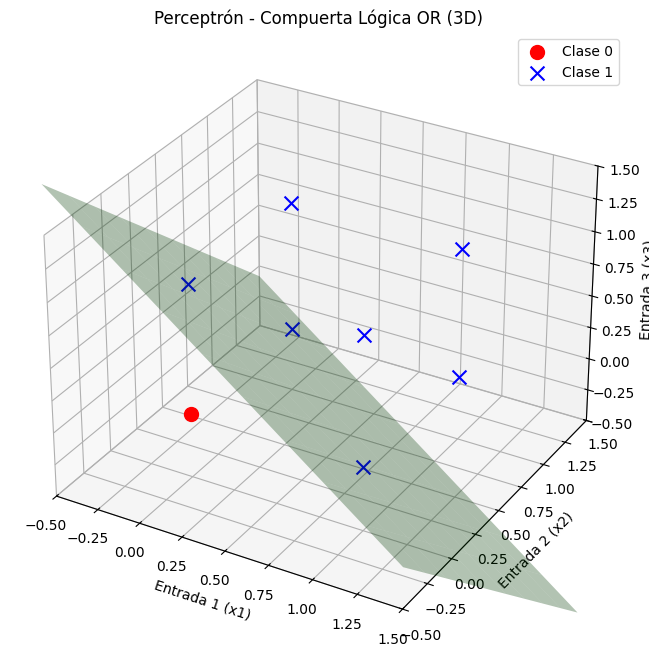

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Graficar los puntos de datos para neurona 2
for i, xi in enumerate(X):
    if y[i,1] == 0:
        ax.scatter(xi[0], xi[1], xi[2], color='red', marker='o', s=100, label='Clase 0' if i == 0 else "")
    else:
        ax.scatter(xi[0], xi[1], xi[2], color='blue', marker='x', s=100, label='Clase 1' if i == 1 else "")

# Definir el plano de decisión para OR
# w1*x1 + w2*x2 + w3*x3 + w0 = 0
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 10), np.linspace(-0.5, 1.5, 10))
zz = -(weights[1,1] * xx + weights[1,2] * yy + weights[1,0]) / weights[1,3]

# Graficar el plano de decisión
ax.plot_surface(xx, yy, zz, alpha=0.3, color='green')

# Configuraciones de la gráfica
ax.set_xlabel('Entrada 1 (x1)')
ax.set_ylabel('Entrada 2 (x2)')
ax.set_zlabel('Entrada 3 (x3)')
ax.legend()
ax.set_title('Compuerta Lógica OR (3D)')
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_zlim(-0.5, 1.5)

plt.show()